# Large-sized Inversions
Here, we visualize the inversions that were identified for the `large` treatment across the range of depths. The `LEVIATHAN` small, medium, and large call rates are configured to `-s 90 -m 90 -l 90`.

In [1]:
library(ggplot2)
options(warn = -1, repr.plot.width = 19, repr.plot.height = 10)
.size <- "large"

In [2]:
read_data <- function(size_treatment, depth){
    .depth <- paste("depth",depth, sep = "_")
    truthfile <- paste0("simulated_variants/inversions_genomes/", size_treatment, "/inv.", size_treatment,".vcf")
    samplesfile <- paste("simulated_data/called_sv/leviathan", size_treatment, .depth, "by_sample90/inversions.bedpe", sep = "/")
    poolfile <- paste("simulated_data/called_sv/leviathan", size_treatment, .depth, "by_pop90/inversions.bedpe", sep = "/")

    true_inversions <- read.table(truthfile, header = F)[,c(1,2,8)]
    true_inversions$V8 <- as.numeric(unlist(lapply(true_inversions$V8, function(X){gsub(".+END=", "", X)})))
    names(true_inversions) <- c("contig", "position_start", "position_end")
    true_inversions$sample <- "simulated_inversions"

    sample_inversions <- read.table(samplesfile, header = T)[,1:4]

    pooled_inversions <- read.table(poolfile, header = T)
    pooled_inversions <- pooled_inversions[,c("population","contig", "position_start", "position_end")]
    names(pooled_inversions)[1] <- "sample"
    if( nrow(pooled_inversions) > 0){
        pooled_inversions$sample <- paste("pooled", depth, size_treatment, sep = "_")
    }

    return(
        rbind(true_inversions, sample_inversions, pooled_inversions)
    )
}

plot_data <- function(data, size_treatment, depth){
    axis_ticks <- factor(c(paste("pooled", depth, size_treatment, sep = "_"), paste0("sample_", sprintf("%02d", 1:10)), "simulated_inversions"))
    ggplot(
        data,
        aes(
            x = position_start,
            xend = position_end,
            y = sample,
            yend = sample,
            color = sample
        )
    ) +
        scale_x_continuous(labels = scales::comma) +
        scale_y_discrete(limits = axis_ticks) +
        labs(title = "Called Inversions", subtitle = paste0("Size: ", size_treatment, " | Depth: ", depth,"X"), x = "genomic position (bp)", caption = "simulated_inversions are groundtruth") + 
        geom_segment(linewidth = 2) +
        facet_wrap(~contig, ncol = 1, scales = "free_x") +
        theme_light() +
        theme(panel.grid.major.y = element_blank(), legend.position = "None")
}

## 0.5X depth

In [3]:
depth_05X <- read_data(.size, 0.5)
tail(depth_05X)

,contig,position_start,position_end,sample
,<chr>,<int>,<dbl>,<chr>
6,3R,21788248,26713174,simulated_inversions
7,3L,176550,2301734,simulated_inversions
8,3L,18163968,21883914,simulated_inversions
9,2L,11529164,15060030,pooled_0.5_large
10,3L,176549,2301734,pooled_0.5_large
11,2R,1439996,4186469,pooled_0.5_large


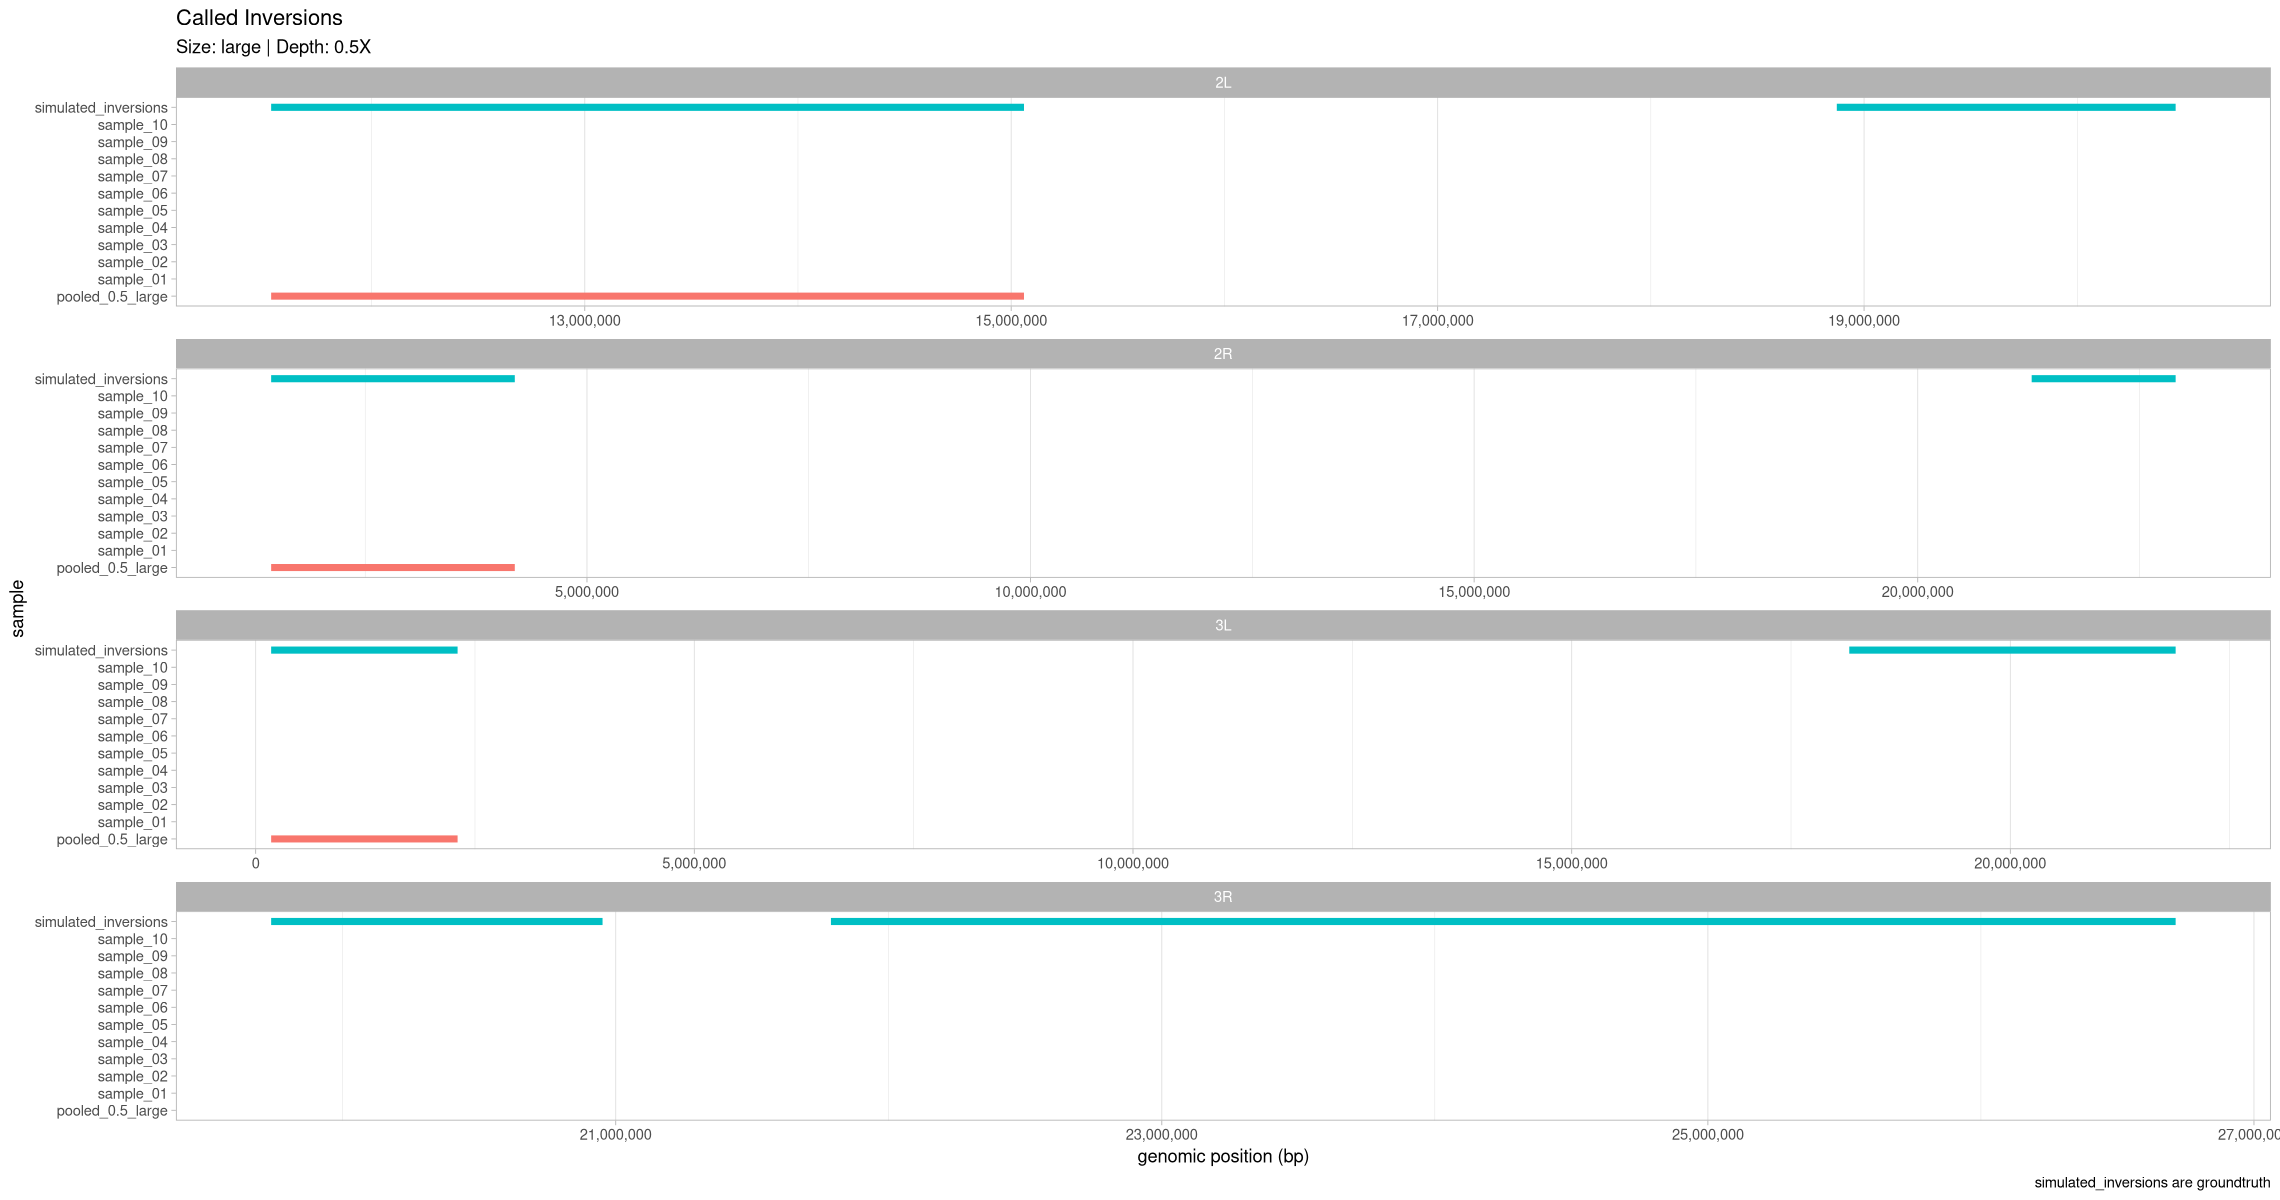

In [4]:
plot_data(depth_05X, .size, 0.5)

## 2X Depth

In [5]:
depth_2X <- read_data(.size, 2)
tail(depth_2X)

,contig,position_start,position_end,sample
,<chr>,<int>,<dbl>,<chr>
29,3L,176549,2301734,pooled_2_large
30,3L,18163967,21883914,pooled_2_large
31,2R,1439996,4186470,pooled_2_large
32,2R,21284515,22907265,pooled_2_large
33,3R,19738051,20951825,pooled_2_large
34,3R,21788246,26713175,pooled_2_large


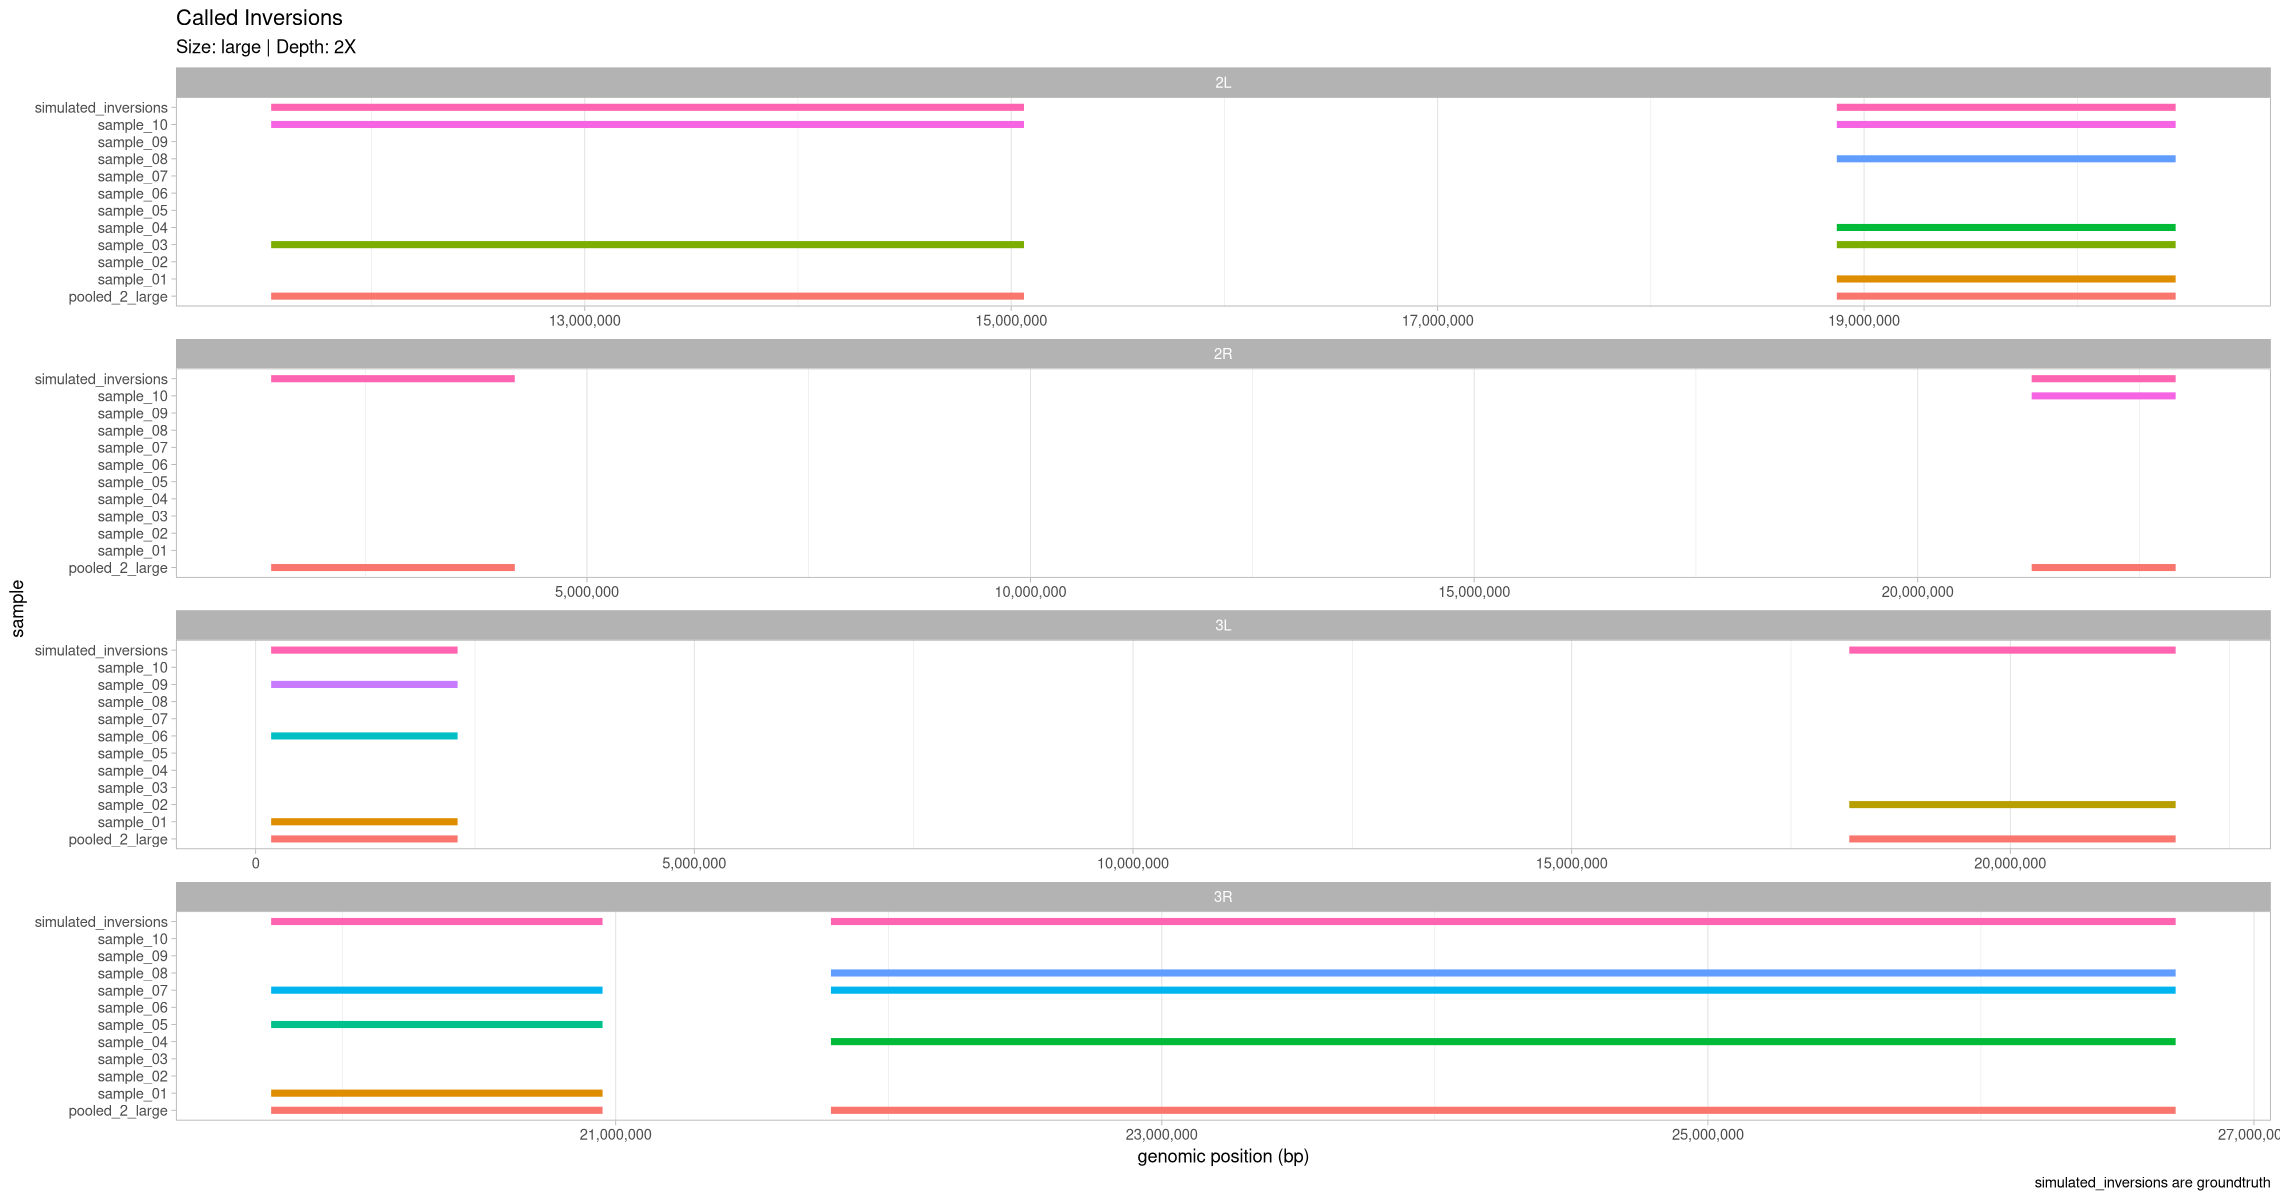

In [6]:
plot_data(depth_2X, .size, 2)

## 5X Depth

In [7]:
depth_5X <- read_data(.size, 5)
tail(depth_5X)

,contig,position_start,position_end,sample
,<chr>,<int>,<dbl>,<chr>
59,3L,176549,2301734,pooled_5_large
60,3L,18163967,21883914,pooled_5_large
61,2R,1439996,4186470,pooled_5_large
62,2R,21284515,22907265,pooled_5_large
63,3R,19738051,20951825,pooled_5_large
64,3R,21788246,26713174,pooled_5_large


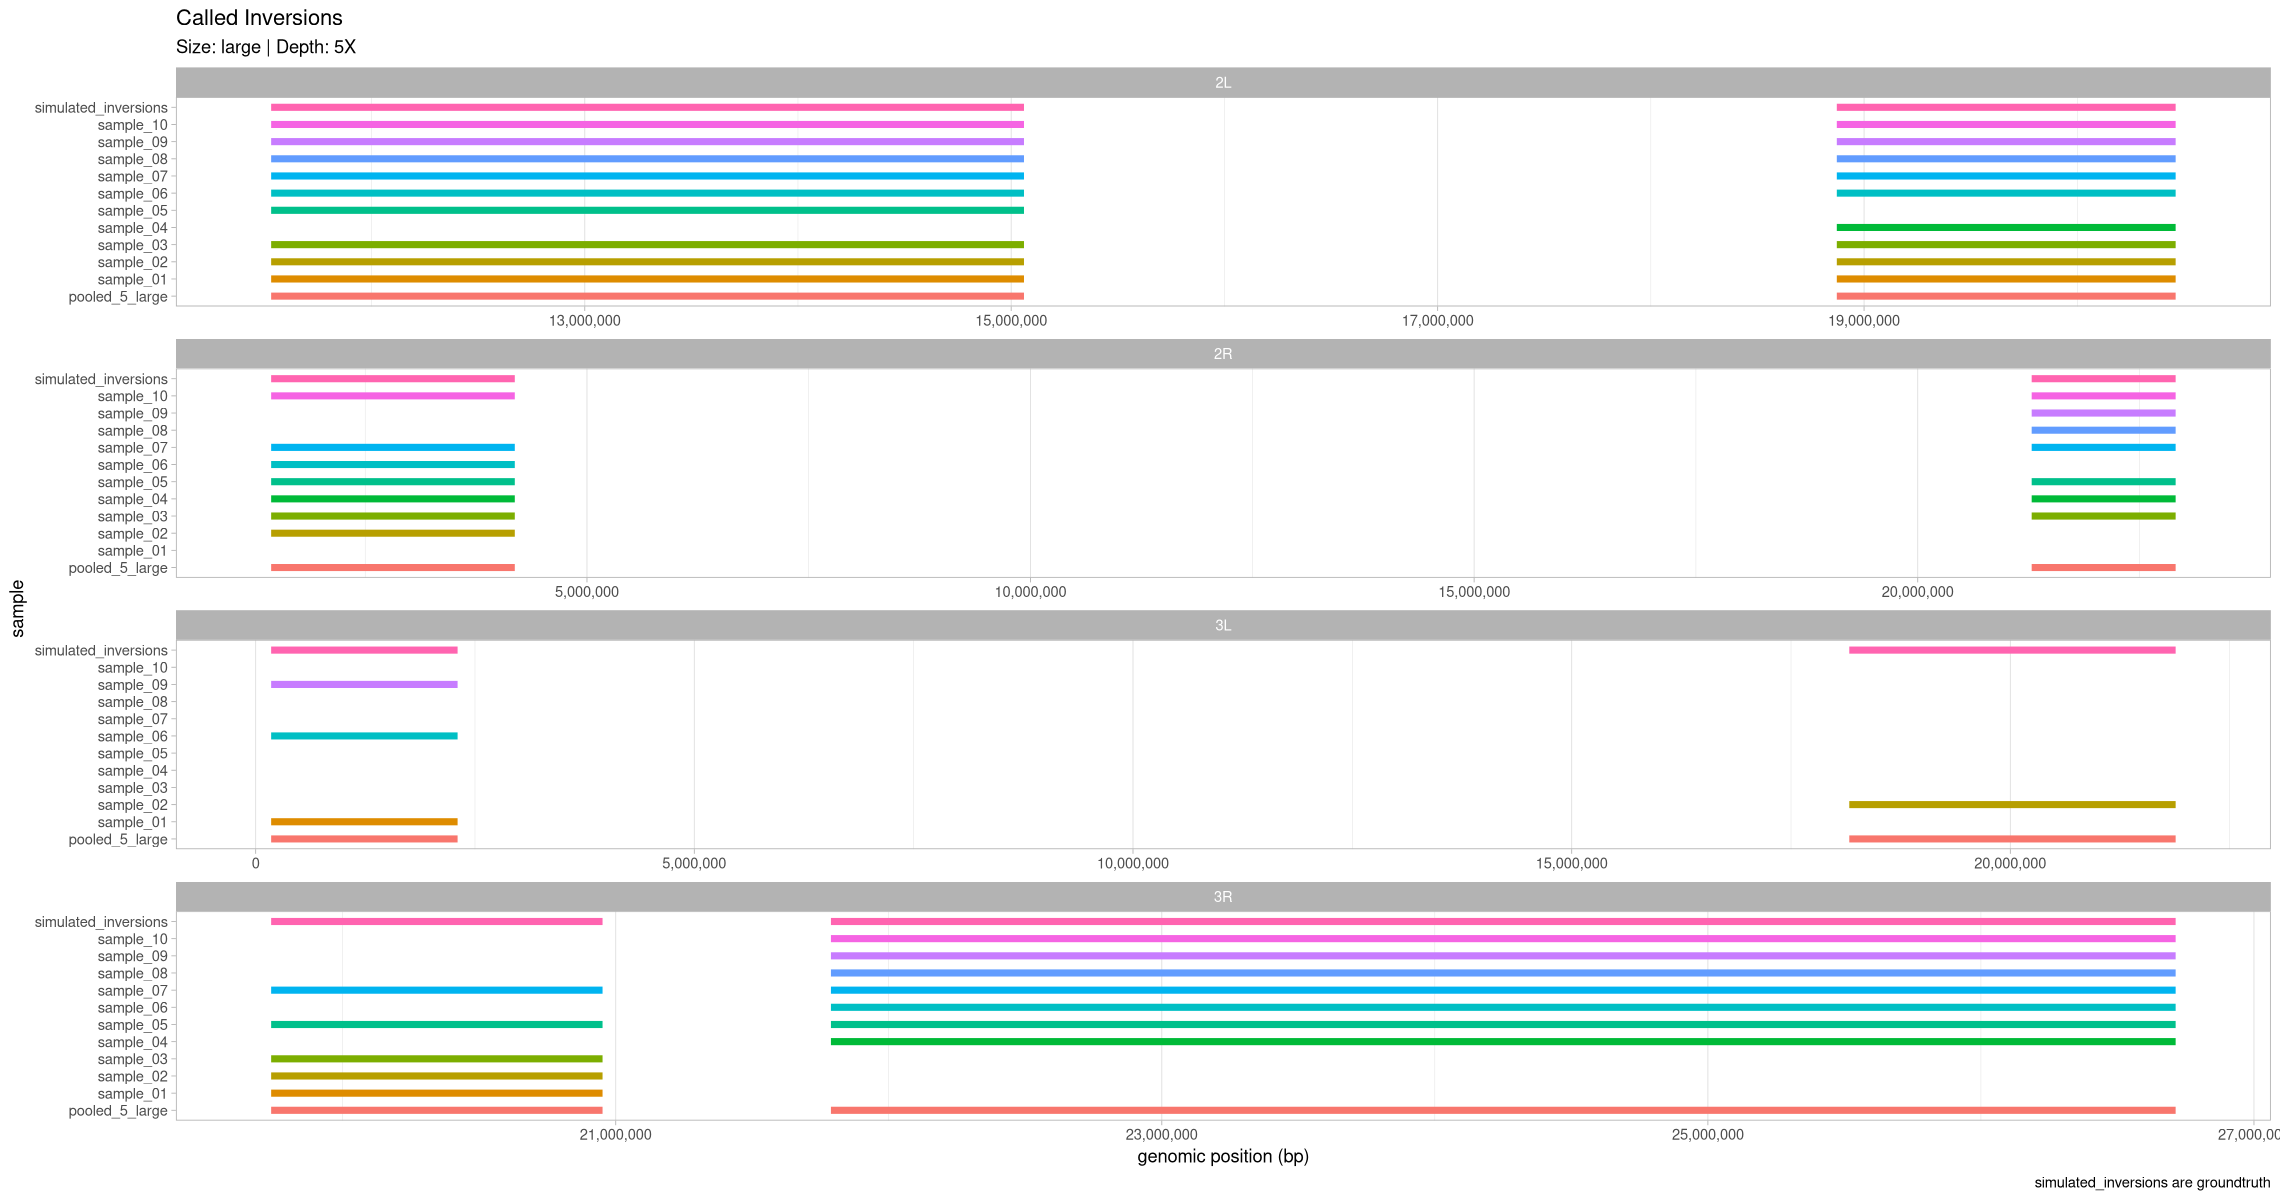

In [8]:
plot_data(depth_5X, .size, 5)

## 10X Depth

In [9]:
depth_10X <- read_data(.size, 10)
tail(depth_10X)

,contig,position_start,position_end,sample
,<chr>,<int>,<dbl>,<chr>
70,3L,176549,2301734,pooled_10_large
71,3L,18163967,21883914,pooled_10_large
72,2R,1439997,4186470,pooled_10_large
73,2R,21284515,22907266,pooled_10_large
74,3R,19738053,20951827,pooled_10_large
75,3R,21788246,26713174,pooled_10_large


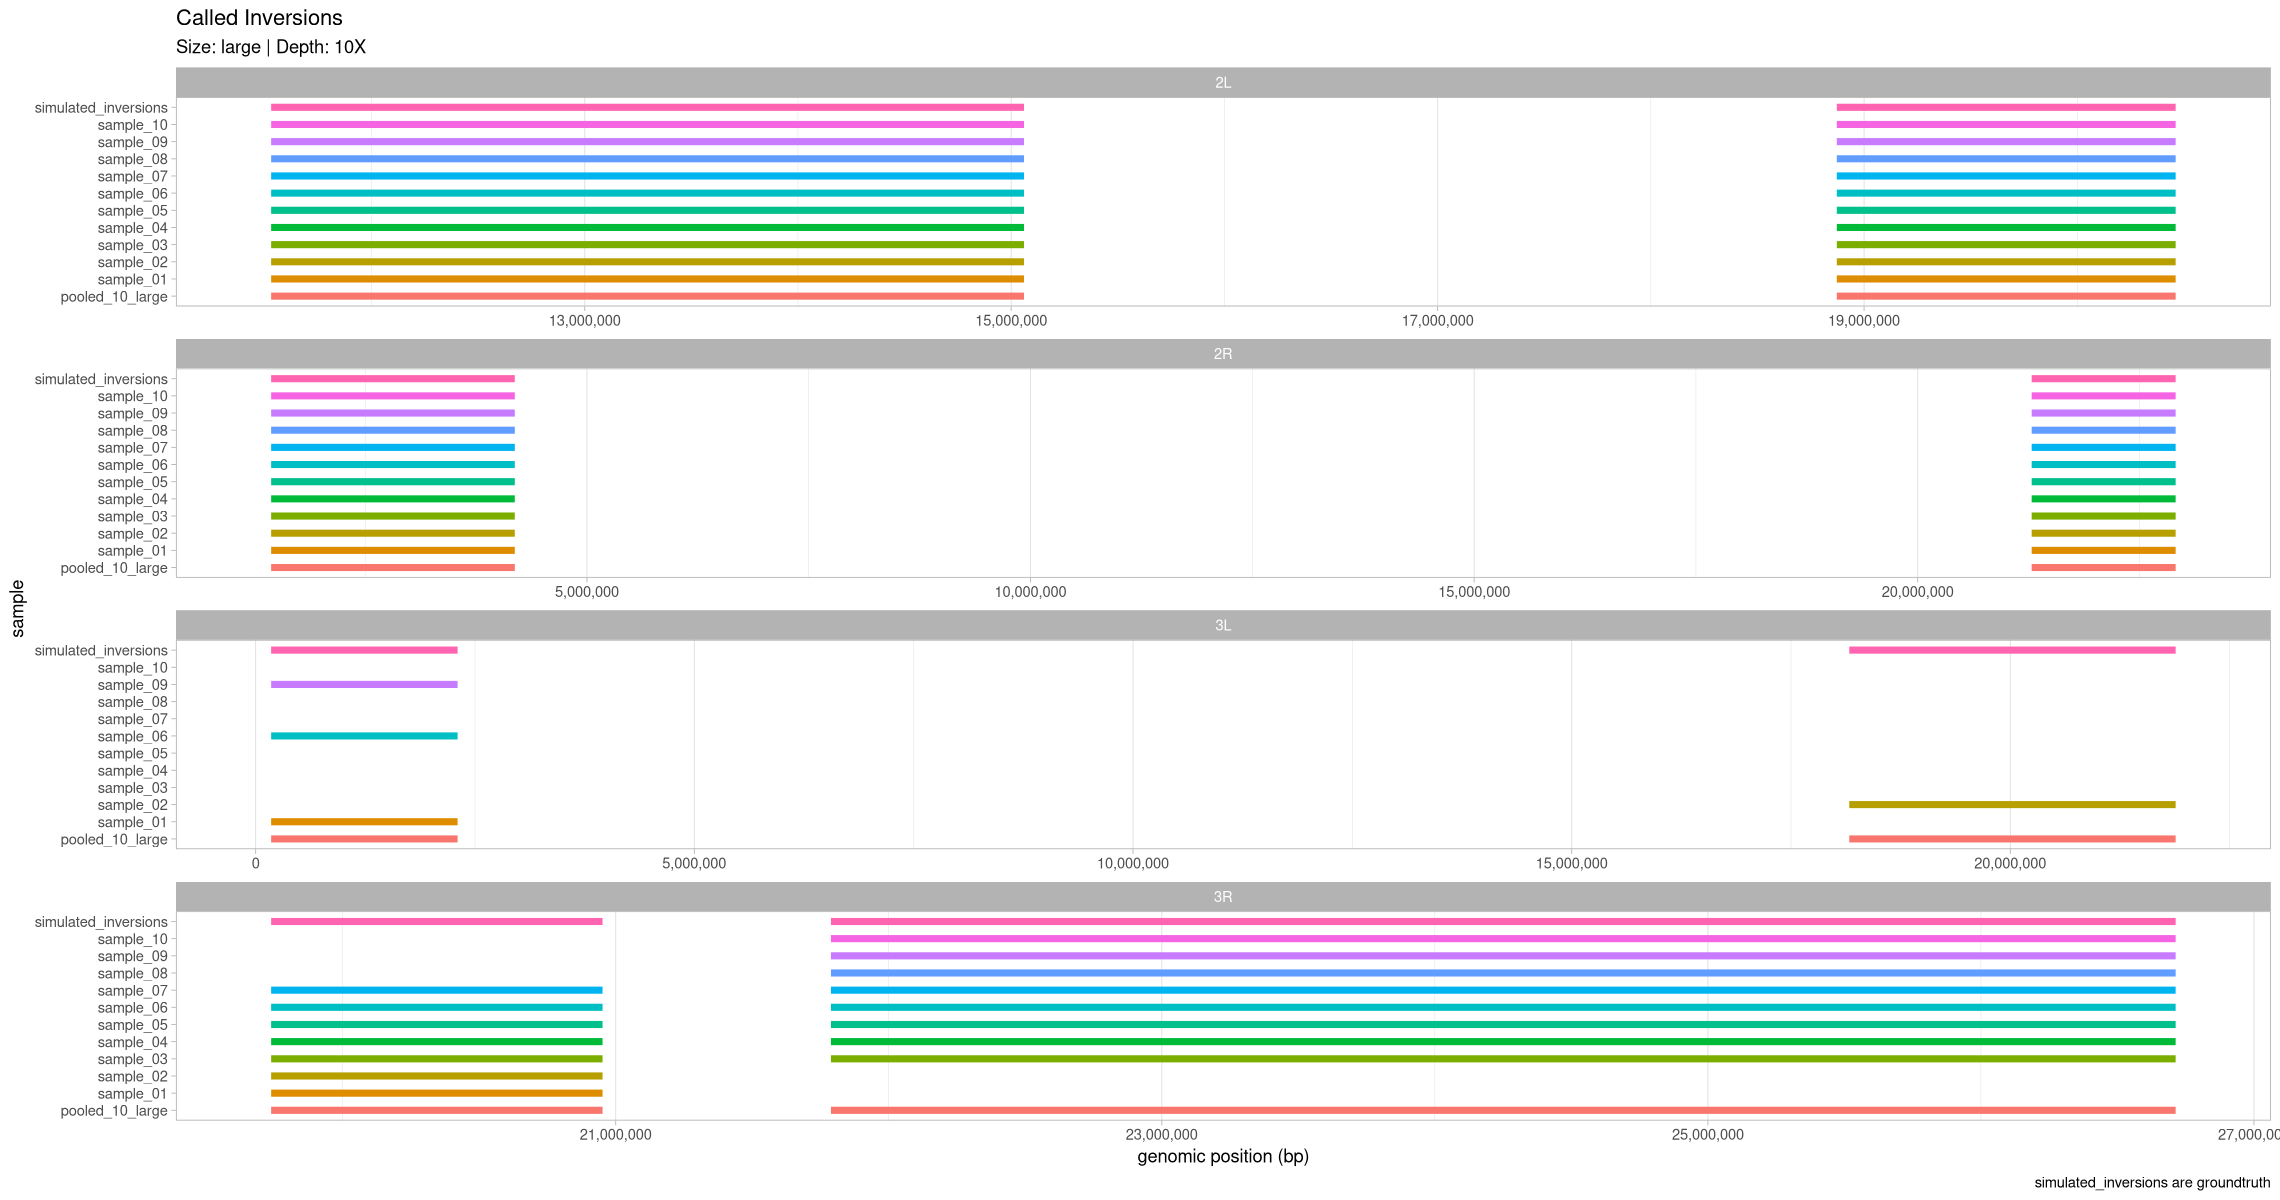

In [10]:
plot_data(depth_10X, .size, 10)

## 20X Depth

In [11]:
depth_20X <- read_data(.size, 20)
tail(depth_20X)

,contig,position_start,position_end,sample
,<chr>,<int>,<dbl>,<chr>
70,3L,176549,2301734,pooled_20_large
71,3L,18163967,21883914,pooled_20_large
72,2R,1439996,4186470,pooled_20_large
73,2R,21284515,22907266,pooled_20_large
74,3R,19738053,20951827,pooled_20_large
75,3R,21788246,26713174,pooled_20_large


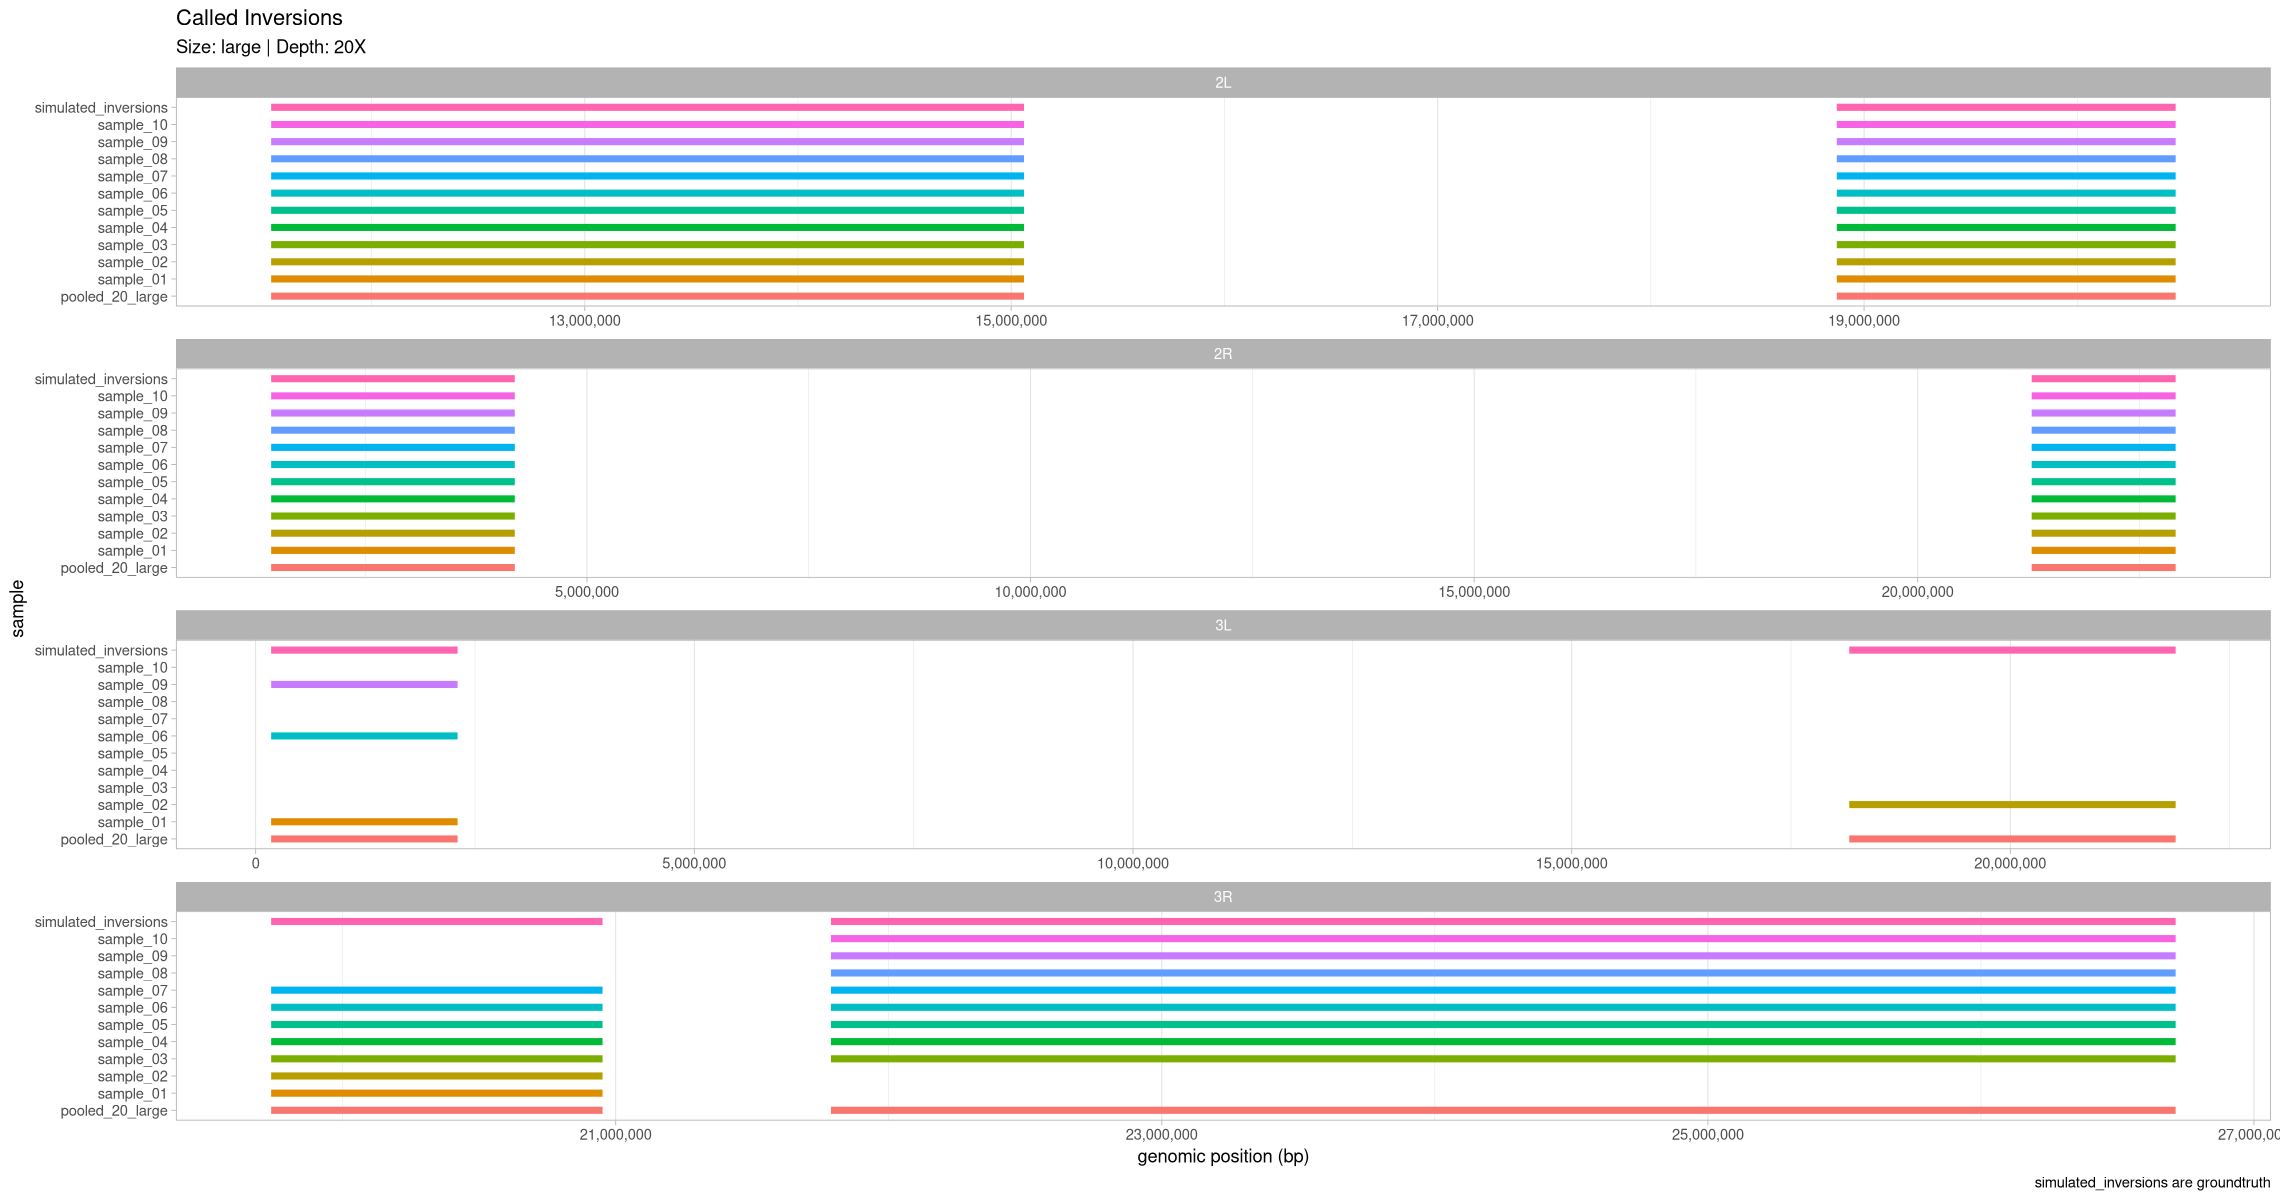

In [12]:
plot_data(depth_20X, .size, 20)